# Detección de anomalías

En el presente notebook, se resuelve un problema de detección de anomalías usando un dataset con datos médicos, ***stroke_prediction_dataset***. La detección se realiza a nivel de atributo, mediante los métodos intercuartilico y desviación de la media. Asimismo, se entrenan modelos de aprendizaje no supervisado como: Local Outlier Factor (LOF), One SVM y Isolation Forest.

In [ ]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

## Dataset para la predicción de accidentes cerebrovasculares

El dataset Stroke Prediction está compuesto de 11 variables clinicas para prevenir los derrames cerebrales. Dichas variables son:

1. *id*: identificador
2. *gender*: "Male" (masculino), "Female" (femenino) u "Other" (otro)
3. *age*: Edad del paciente
4. *hypertension*: 0 si el paciente no tiene hipertensión, 1 en caso contrario
5. *heart_disease*: 0 si el paciente no padece enfermedades del corazón, 1 en caso contrario
6. *ever_married*: "No" o "Yes"
7. *work_type*: Tipo de trabajo. Los valores que puede tomar son: "children", "Govt_jov", "Never_worked", "Private" o "Self-employed"
8. *Residence_type*: Tipo de residencia, puede ser: "Rural" o "Urban"
9. *avg_glucose_level*: Promedio del nivel de glucosa en la sangre
10. *bmi*: índice de masa corporal
11. *smoking_status*: Indica si el paciente a fumado o no, los valores que puede tomar son: "formerly smoked" (antes fumaba), "never smoked" (nunca ha fumado), "smokes" (fuma) or "Unknown" (desconocido)
12. ***stroke***: 1 si el paciente ha sufrido un derrame cerebral o 0 si no

NOTA: "Unknown" La información del paciente no se encuentra disponible.

FUENTE: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset?resource=download#

## Cargar el dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('./drive/MyDrive/ML/healthcare-dataset-stroke-data.csv')

## Tratamiento de nulos

In [ ]:
df_mean_bmi = df.groupby(['age', 'gender'])['bmi'].mean()
df_mean_bmi.head()

age   gender
0.08  Female    14.100000
      Male      16.900000
0.16  Male      14.766667
0.24  Male      17.400000
0.32  Female    17.266667
Name: bmi, dtype: float64

In [ ]:
# La siguente función sustituye los null por la media calculada en el dataframe anterior.

def sustituir_nan_bmi(df, df_mean_bmi):
    if np.isnan(df['bmi']):
        return df_mean_bmi[df['age']][df['gender']]
    else:
        return df['bmi']

In [ ]:
df['bmi'] = df.apply(sustituir_nan_bmi, axis=1, args=(df_mean_bmi, ))
df.loc[2030, 'bmi'] = df_mean_bmi[0.48]['Female']
#df.isna().sum()

Eliminar columna id, ya que no aporta información. Además de la fila que   tiene en *'gender'* el valor de "***Other***"

In [ ]:
df = df.drop(columns=['id'])
idx = df.index[df["gender"]=="Other"].tolist()
df = df.drop(idx)

Balance dataset

In [ ]:
df_balance = pd.DataFrame(df['stroke'].value_counts())

<Axes: xlabel='stroke'>

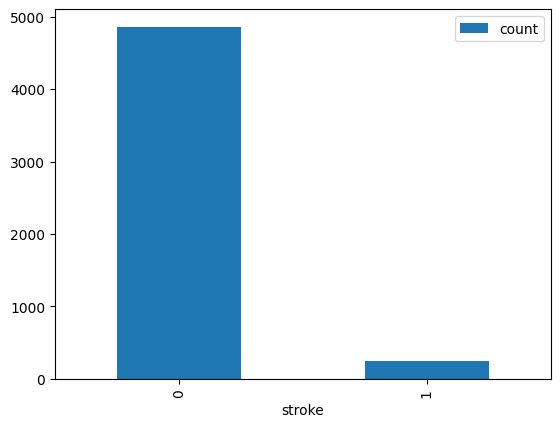

In [ ]:
df_balance.plot(kind='bar')

## Análisis exploratorio del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.0+ KB


Datos estadísticos de variables numéricas, se incluyen las numericas booleanas: *hypertension*, *heart_disease* y *stroke*, que se consideran **categóricas dicotómicas**.

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,5109.0,43.229986,22.613575,0.08,25.00,45.00,61.00,82.00
hypertension,5109.0,0.097475,0.296633,0.00,0.00,0.00,0.00,1.00
heart_disease,5109.0,0.054022,0.226084,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,5109.0,106.140399,45.285004,55.12,77.24,91.88,114.09,271.74
bmi,5109.0,28.920039,7.731435,10.30,23.70,28.30,32.90,97.60
stroke,5109.0,0.048738,0.215340,0.00,0.00,0.00,0.00,1.00


Se identifican las variables categóricas y las numéricas

In [ ]:
lst_catvar = df.select_dtypes(include=int).columns.to_list()+df.select_dtypes(include=object).columns.to_list()
lst_nvar = df.select_dtypes(include=int).columns.to_list()+df.select_dtypes(include=float).columns.to_list()

### Frecuencias de variables categóricas

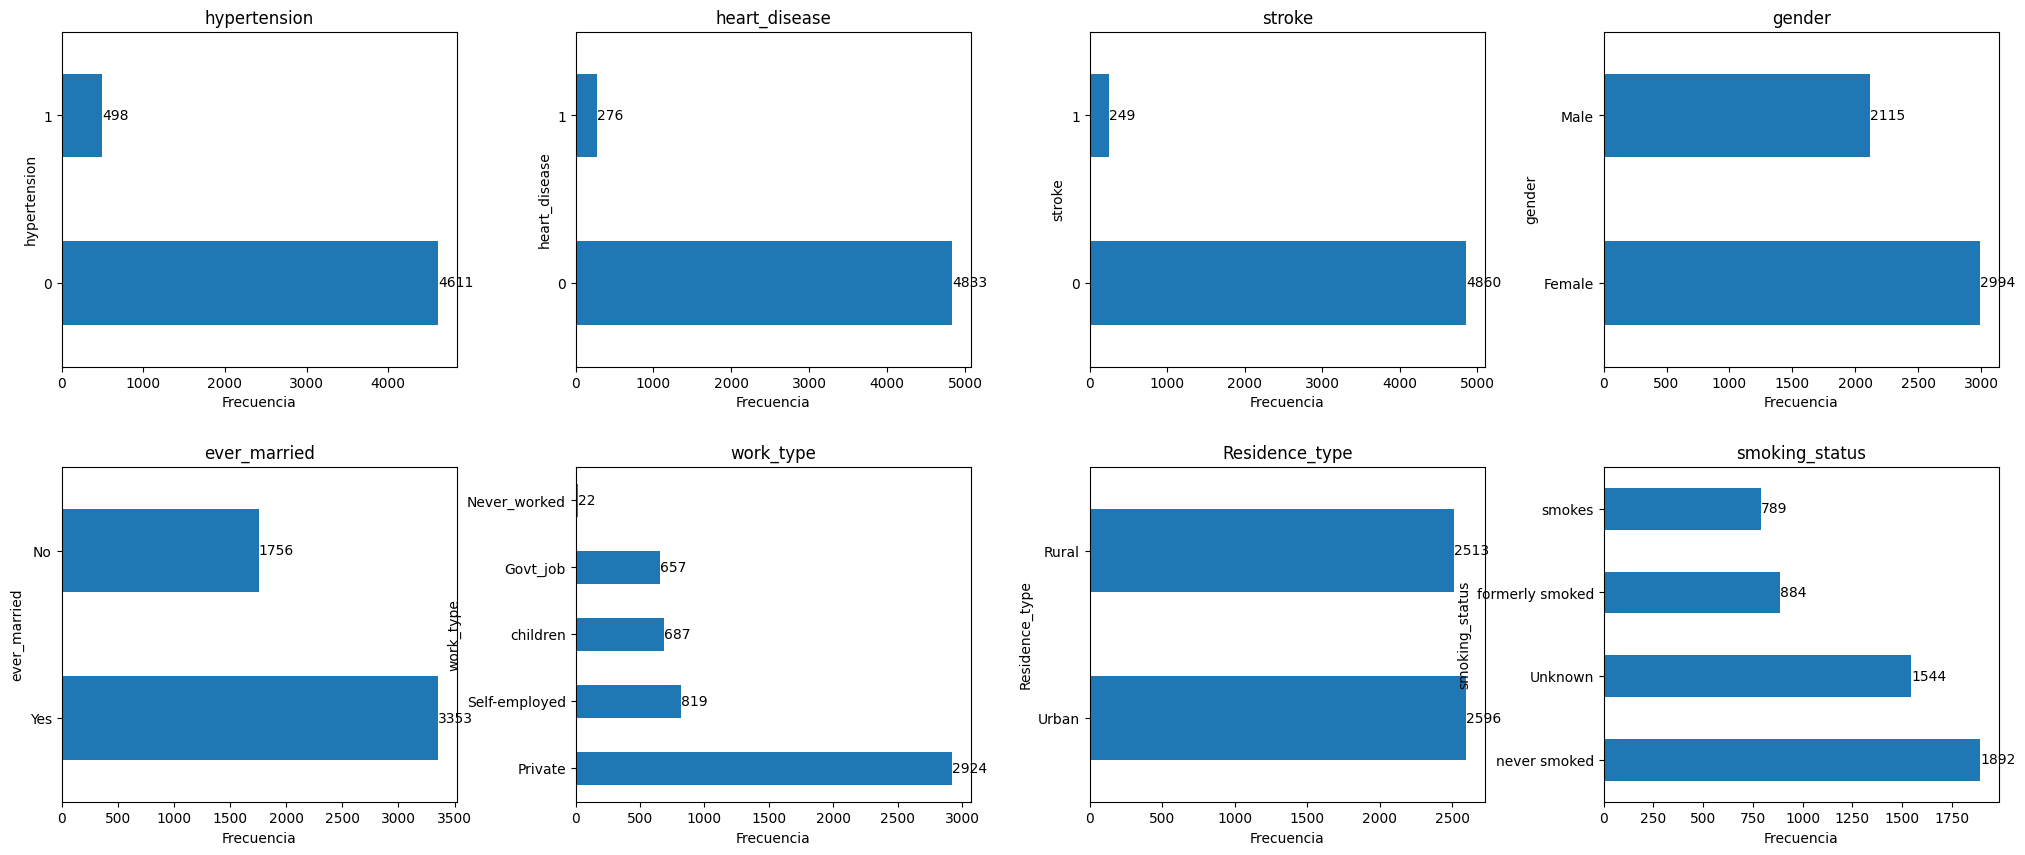

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(25, 10))

plt.subplots_adjust(
    wspace = 0.3,
    hspace = 0.3
)

for col, ax in zip(lst_catvar, axes.ravel()):
  df[col].value_counts().plot.barh(ax=ax)
  ax.set_xlabel('Frecuencia')
  # ax.set_ylabel('Valor')
  ax.set_title(col)
  ax.bar_label(ax.containers[0])

plt.show()

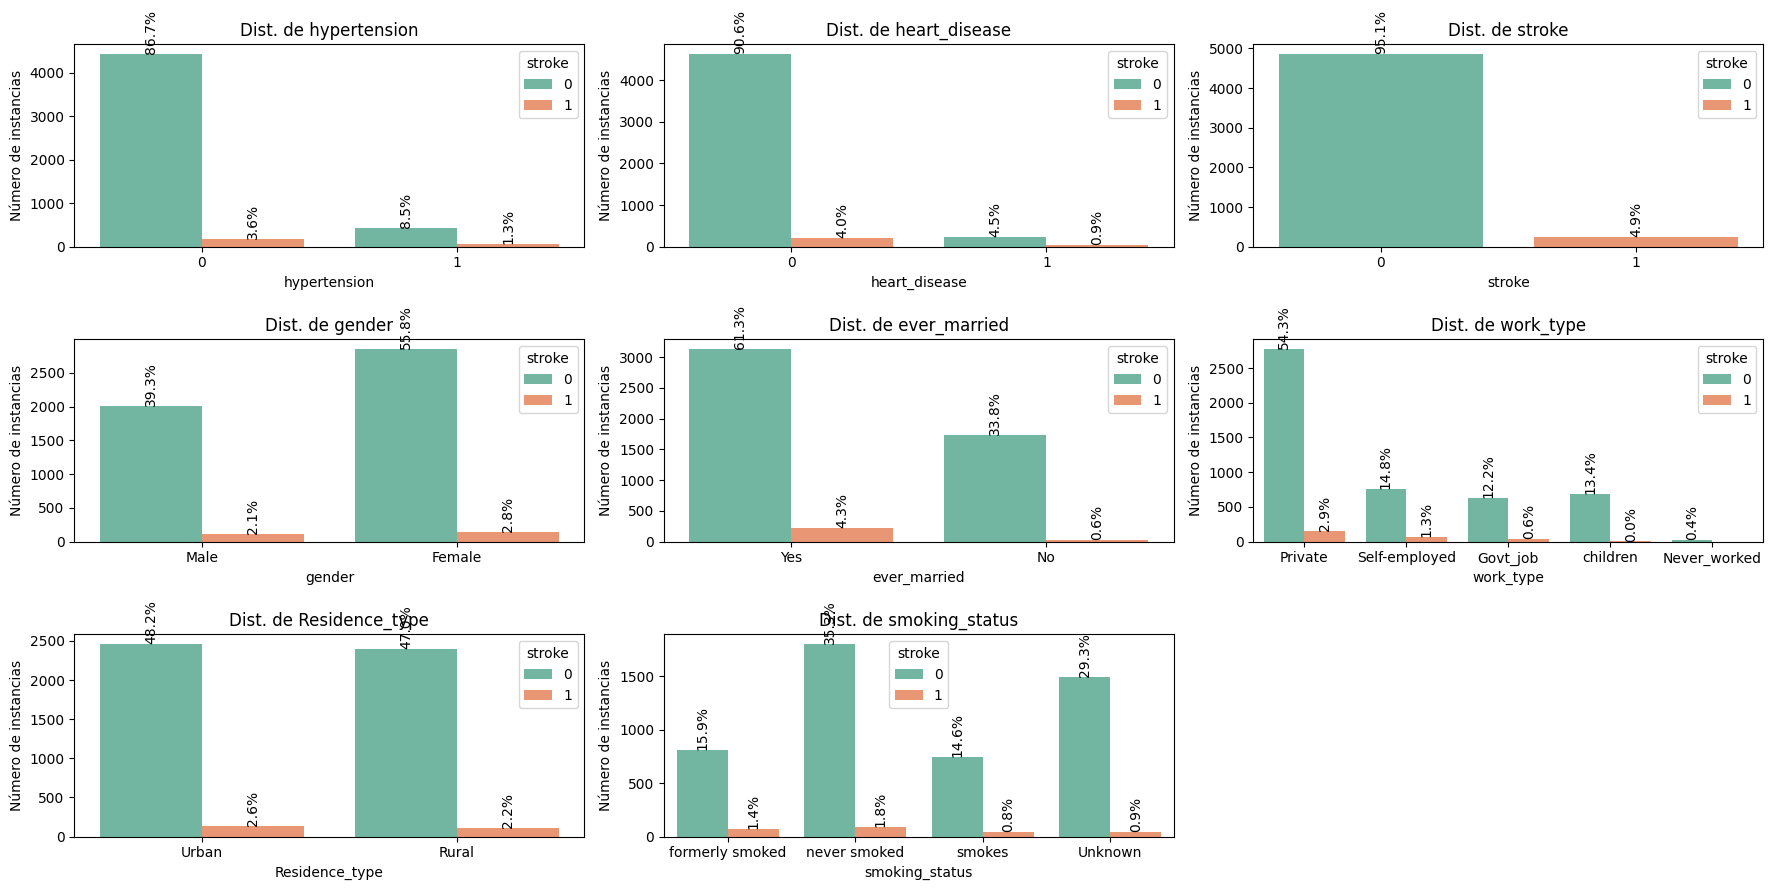

In [ ]:
cols = 3
rows = (len(lst_catvar) // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 3))
axes = axes.flatten()  # Aplana la matriz de ejes para facilitar el acceso

for idx, column in enumerate(lst_catvar):
    ax = sb.countplot(x=column, hue='NSP', data=df[lst_catvar], palette="Set2", ax=axes[idx])
    axes[idx].set_title(f"Dist. de {column}")
    axes[idx].set_xlabel(column)
    axes[idx].set_ylabel('Número de instancias')

    # Agregar porcentajes sobre cada barra con rotación
    total = len(df[lst_catvar])
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Solo añadir el porcentaje si la altura es mayor que cero
            # Calcular el porcentaje
            percentage = f'{100 * height / total:.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = p.get_y() + height
            # Añadir el porcentaje como anotación con rotación
            ax.annotate(percentage, (x, y), ha='center', va='bottom', rotation=90)

# Eliminar ejes vacíos si es necesario
for ax in axes[len(lst_catvar):]:
    fig.delaxes(ax)

# Ajustar el diseño para dejar espacio para la leyenda
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Ajusta el espacio para la leyenda a la derecha
plt.show()

### Histogramas de variables continuas

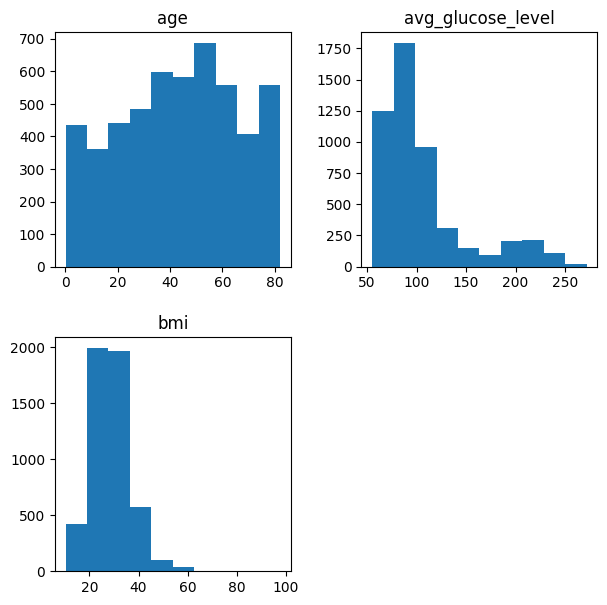

In [ ]:
df[df.select_dtypes(include=float).columns.to_list()].hist(grid=False, figsize=(7, 7))
plt.show()

### Diagramas de caja y bigotes

<Axes: title={'center': 'Diagramas de caja y bigotes'}>

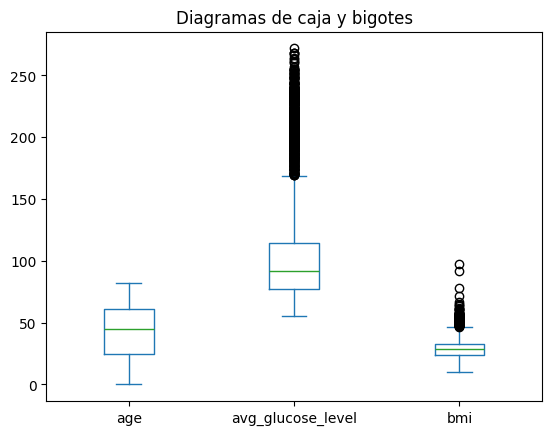

In [ ]:
# Visualizar la distribución y los posibles datos atípicos
df[df.select_dtypes(include=float).columns.to_list()].plot(kind='box', title="Diagramas de caja y bigotes")

### Correlación entre variables

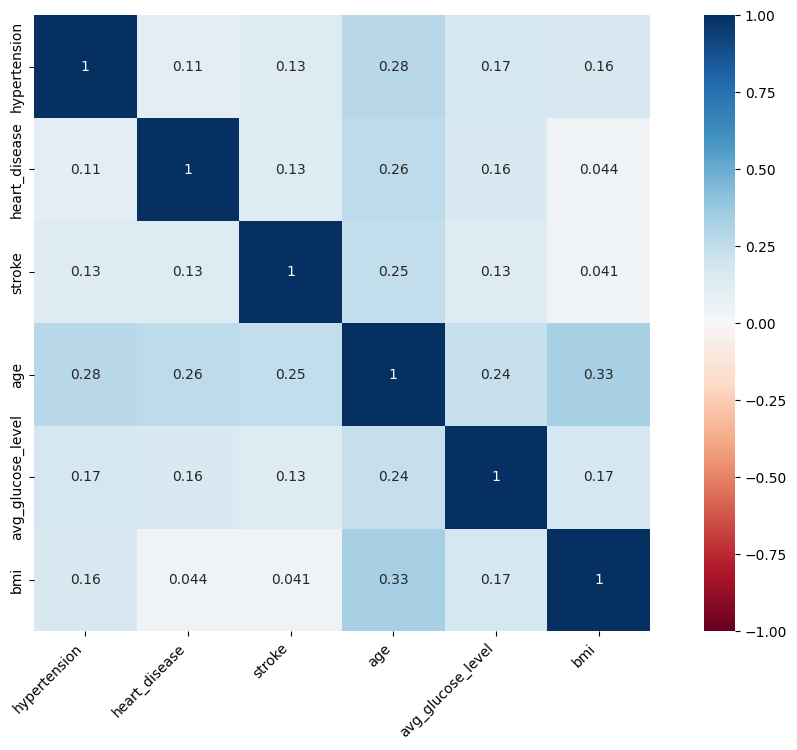

In [ ]:
plt.figure(figsize=(14, 8))
corr = df[lst_nvar].corr()
colores = sb.diverging_palette(20, 220, n=200)
ax = sb.heatmap(corr, annot=True, cmap=plt.cm.RdBu, vmin=-1, vmax=1, center=0, square=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');

### Convertir variables categoricas en numericas

In [ ]:
df_2 = df.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_cat = df_2.select_dtypes(include=['object']).apply(label_encoder.fit_transform)
df_2[df_cat.columns] = df_cat

X_2 = df_2.drop('stroke', axis=1).to_numpy()
y_2 = df_2['stroke'].to_numpy()

In [ ]:
df_2.sample(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2339,1,43.0,0,0,1,0,0,80.07,32.011111,2,0
1895,1,56.0,0,0,1,2,0,82.44,34.500000,2,0
2431,1,36.0,0,0,1,2,1,98.03,22.100000,3,0
4784,0,81.0,1,1,1,2,0,126.34,27.400000,3,0
4020,1,9.0,0,0,0,4,0,76.88,18.000000,0,0
4057,0,36.0,0,0,1,2,0,101.93,22.800000,3,0
3620,1,38.0,0,0,1,2,0,133.62,25.200000,2,0
2491,0,50.0,0,0,1,3,0,95.25,24.300000,2,0
2654,1,52.0,0,0,1,0,1,67.50,27.700000,3,0
3349,1,37.0,0,0,1,0,1,82.09,35.700000,3,0


In [ ]:
df_2_corr = df[['age', 'bmi', 'stroke']]
X_2_corr = df_2_corr.iloc[:, :-1].to_numpy()
y_2_corr = df['stroke'].to_numpy()

## Métodos de detección por instancia

### Método intercuartil

Se emplea el cálculo del rango intercuartil para detectar los outliers. En este caso un valor es outlier si está por debajo del $$Q1 − 1.5 \times IQR$$
o por encima de $$Q3 + 1.5 \times IQR$$

In [ ]:
def out_iqr(df , column):
    global lower,upper
    q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
    # IQR
    iqr = q75 - q25
    # Límite para los outliers
    cut_off = iqr * 1.5
    # Calculo de los valores superior e inferior
    lower = df[column].min() if q25 - cut_off < 0 else q25 - cut_off
    upper = q75 + cut_off
    print(f'IQR {iqr:.2f}')
    print(f'El limite inferior es {lower:.2f}')
    print(f'El limite superior es {upper:.2f}')
    # Calculo del número de registros por debajo y por encima de los valores, respectivamente
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Número total de outliers detectados', df1.shape[0]+ df2.shape[0])

In [ ]:
for col in df.select_dtypes(include=float).columns.to_list():
  print(col)
  out_iqr(df, col)
  print(25*'--')
  print(25*'--')

age
IQR 36.00
El limite inferior es 0.08
El limite superior es 115.00
Número total de outliers detectados 0
--------------------------------------------------
--------------------------------------------------
avg_glucose_level
IQR 36.85
El limite inferior es 21.96
El limite superior es 169.37
Número total de outliers detectados 627
--------------------------------------------------
--------------------------------------------------
bmi
IQR 9.20
El limite inferior es 9.90
El limite superior es 46.70
Número total de outliers detectados 120
--------------------------------------------------
--------------------------------------------------


## Método de la desviación estándar

Se emplea para identificar aquellos puntos de datos que se separan de la media.

In [ ]:
def out_std(df, column):
    global lower,upper
    # cálculo de la media y desviación estándar
    data_mean, data_std = df[column].mean(), df[column].std()
    # calculo del punto de corte
    cut_off = data_std * 3
    # Cálculo del punto por debajo y por encima del punto de corte
    lower = 0 if data_mean - cut_off < 0 else data_mean - cut_off
    upper = data_mean + cut_off
    print(f'El límite inferior es {lower:.2f}')
    print(f'El limite superior es {upper:.2f}')
    # cálculo del número de registros por debajo y por encima.
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Número total de outliers', df1.shape[0]+ df2.shape[0])

In [ ]:
for col in df.select_dtypes(include=float).columns.to_list():
  print(col)
  out_std(df, col)
  print(25*'--')
  print(25*'--')

age
El límite inferior es 0.00
El limite superior es 111.07
Número total de outliers 0
--------------------------------------------------
--------------------------------------------------
avg_glucose_level
El límite inferior es 0.00
El limite superior es 242.00
Número total de outliers 49
--------------------------------------------------
--------------------------------------------------
bmi
El límite inferior es 5.73
El limite superior es 52.11
Número total de outliers 59
--------------------------------------------------
--------------------------------------------------


## Isolation Forest

Método no supervisado para identificar *outliers*. Su funcionamiento está inspirado en el algoritmo *Random Forest*, esto es, está formado por la combinación de múltiples árboles llamados *isolation trees*. A diferencia de los arboles de *random forest*, en los *isolation tree* la selección de los puntos de división se hace de forma aleatoria y aquellas observaciones con características distintas al resto quedan aisladas.

**Método *IsolationForest***


En el método Isolation Forest, el parámetro **contamination** permite ajustar la detección de *outliers*, indicando la proporción estimada de anomalías en los datos. Este valor puede especificarse como un número real entre 0 y 1; por ejemplo, un valor de 0.05 indica que el modelo asumirá que el 5 % de las observaciones son *outliers*. Alternativamente, puede establecerse en "*auto*", para que el modelo estime automáticamente dicha proporción a partir del conjunto de datos.

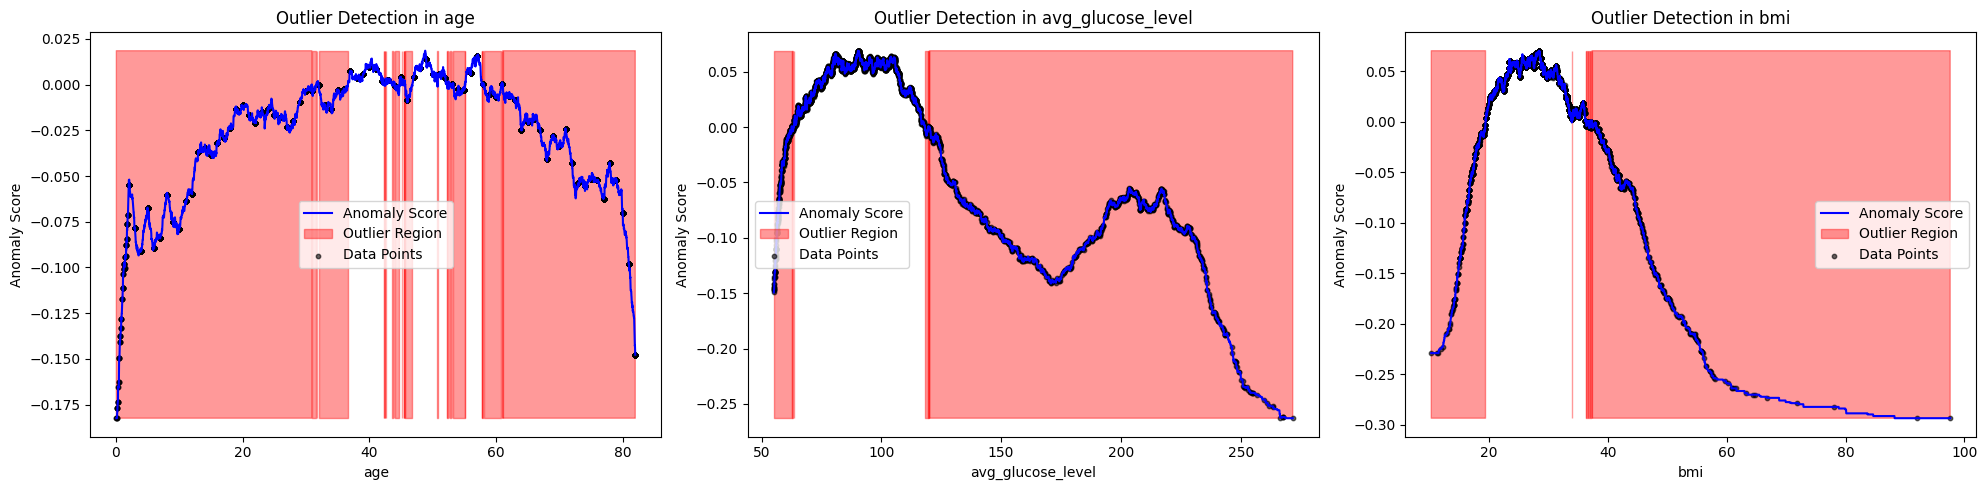

In [ ]:
lst_contvar = df.select_dtypes(include=float).columns.to_list()

fig, axs = plt.subplots(1, len(lst_contvar), figsize=(20, 5), facecolor='w', edgecolor='k')
axs = axs.ravel()

for i, column in enumerate(lst_contvar):
    isolation_forest = IsolationForest(contamination='auto', random_state=42)
    # isolation_forest = IsolationForest(contamination=0.05, random_state=42)
    isolation_forest.fit(df[column].values.reshape(-1, 1))

    # Se genera un conjunto de valores en el mismo rango que la variable
    xx = np.linspace(df[column].min(), df[column].max(), len(df[lst_contvar])).reshape(-1,1)

    # Calculamos la puntuación de anomalía
    anomaly_score = isolation_forest.decision_function(xx)
    outlier = isolation_forest.predict(xx)

    # Graficamos los resultados
    axs[i].plot(xx, anomaly_score, label='Anomaly Score', color='blue')
    axs[i].fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score),
                        where=outlier == -1, color='red', alpha=0.4, label='Outlier Region')

    # Añadir scatter plot con los datos reales y su puntuación de anomalía
    data_anomaly_score = isolation_forest.decision_function(df[column].values.reshape(-1, 1))
    axs[i].scatter(df[column], data_anomaly_score, color='black', s=10, alpha=0.6, label='Data Points')


    axs[i].legend()
    axs[i].set_title(f"Outlier Detection in {column}")
    axs[i].set_xlabel(column)
    axs[i].set_ylabel("Anomaly Score")

plt.tight_layout()
plt.show()

**Fondo rojo (Región de *outliers*)**
* Son las regiones donde *Isolation Forest* ha detectado anomalías.
* Los puntos de esta region tienen una puntuación de anomalía baja, menor a 0), lo que indica que están más aislados del resto de los datos.

**Fondo blanco (Región normal)**
* Se encuentran los datos que se consideran normales


## Detección de anomalías por instancia

In [ ]:
X = df_2.drop('stroke', axis=1).to_numpy()
y = df_2['stroke'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Normalización de los datos

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
ift = IsolationForest(random_state=42, contamination="auto")
ift.fit(X_train)

ift_pred = ift.predict(X_train)

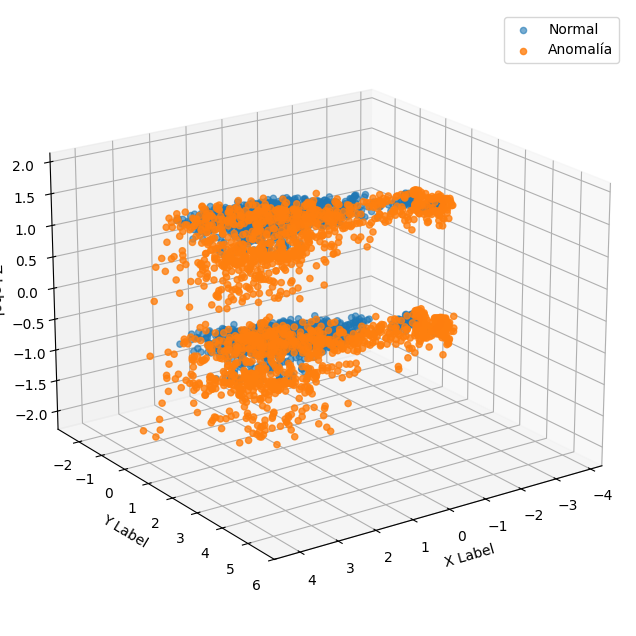

In [ ]:
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3, random_state=42)
X3d_pca = pca_3d.fit_transform(X_train)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d') # or fig.add_subplot(111, projection='3d')

# -------------------------
# Gráfica
# -------------------------
#ax.figure(figsize=(7, 5))
ax.scatter(
    X3d_pca[ift_pred == 1, 0],
    X3d_pca[ift_pred == 1, 1],
    X3d_pca[ift_pred == 1, 2],
    alpha=0.6,
    label='Normal'
)
ax.scatter(
    X3d_pca[ift_pred == -1, 0],
    X3d_pca[ift_pred == -1, 1],
    X3d_pca[ift_pred == -1, 2],
    alpha=0.8,
    label='Anomalía'
)

ax.view_init(elev=20, azim=55)

# 4. Set labels for the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

ax.legend()
# 5. Display the plot
plt.show()

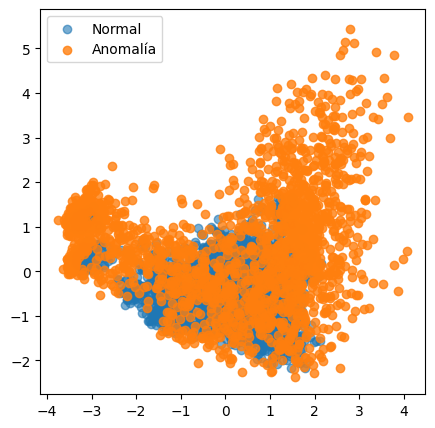

In [ ]:
# from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)


# -------------------------
# Gráfica
# -------------------------
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[ift_pred == 1, 0],
    X_pca[ift_pred == 1, 1],
    alpha=0.6,
    label='Normal'
)
plt.scatter(
    X_pca[ift_pred == -1, 0],
    X_pca[ift_pred == -1, 1],
    alpha=0.8,
    label='Anomalía'
)

plt.axis("square")
plt.legend()
plt.show()

El *score* de un punto muestra qué tan fácil es aislarlo dentro de los árboles aleatorios. Los valores pueden ser positivos o negativos: un valor negativo indica que el punto es un *outlier*, mientras que un valor positivo corresponde a un dato normal (*inlier*). Si el valor está cerca de 0, significa que es más difícil decidir si se trata de un outlier o no.

En muchos casos, el histograma de los scores puede verse como una distribución bimodal, con concentraciones de valores a ambos lados del cero.

In [ ]:
lst_outliers = []
lst_ift = []
lst_ift.append("Isolation Forest")
lst_ift.append(int((ift_pred == 1).sum()))
lst_ift.append(int((ift_pred == -1).sum()))
lst_outliers.append(lst_ift)

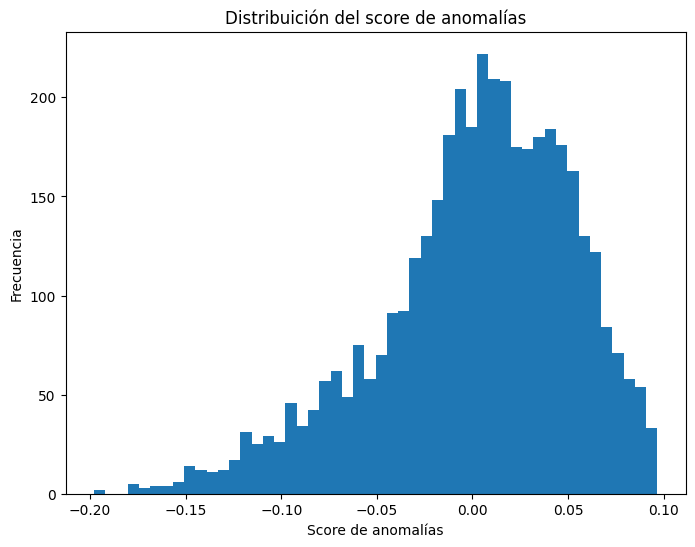

In [ ]:
scores = ift.decision_function(X_train)

plt.figure(figsize=(8, 6))
plt.hist(scores, bins=50)
plt.title("Distribuición del score de anomalías")
plt.xlabel("Score de anomalías")
plt.ylabel("Frecuencia")
plt.show()

Isolation Forest identificó un número elevado de observaciones atípicas, lo cual sugiere una alta variabilidad global y la presencia de regiones de baja densidad en el espacio de características.

## Local Outlier Factor (LOF)


LOF es un método no supervisado basado en densidad, el cual mide qué tan aislado está un punto en relación a sus vecinos, esto es, se calcula la desviación de la densidad local de un punto de datos dado con respecto a sus vecinos. Se consideran como *outliers* aquellas muestras que tienen una densidad sustancialmente inferior a la de sus vecinos.

Parámetros

* **n_neighbors** Parámetro de tipo entero (int) que indica el número de vecinos que se utilizarán para las consultas de vecinos. Si *n_neighbors* es mayor que el número de muestras proporcionadas, se utilizarán todas las muestras. El valor por defecto es 20.
* **algorithm** Algoritmo utilizado para calcular los vecinos más cercanos:
  * *ball_tree* utilizará BallTree.
  * *kd_tree* utilizará KDTree.
  * *brute* utilizará una búsqueda por fuerza bruta.
  * *auto* intentará decidir el algoritmo más adecuado basándose en los valores pasados al método fit. Algoritmo por default.
* **leaf_size** Parámetro de tipo entero (int) que representa el tamaño pasado a BallTree o KDTree, el valor por default es 30. Esto puede afectar a la velocidad de la construcción y la consulta, así como a la memoria necesaria para almacenar el árbol. El valor óptimo depende de la naturaleza del problema.
metricstr o callable, por defecto *minkowski*
* **contamination** Parámetro que indica la cantidad de contaminación del conjunto de datos, es decir, la proporción de valores atípicos en el conjunto de datos. Puede tomar el valor de 'auto' o un valor flotante en el rango de (0, 0.5]

In [ ]:
lof = LocalOutlierFactor(n_neighbors=50, contamination='auto')
lof_pred = lof.fit_predict(X_train)

In [ ]:
lst_lof = []
lst_lof.append("LOF")
lst_lof.append(int((lof_pred == 1).sum()))
lst_lof.append(int((lof_pred == -1).sum()))
lst_outliers.append(lst_lof)

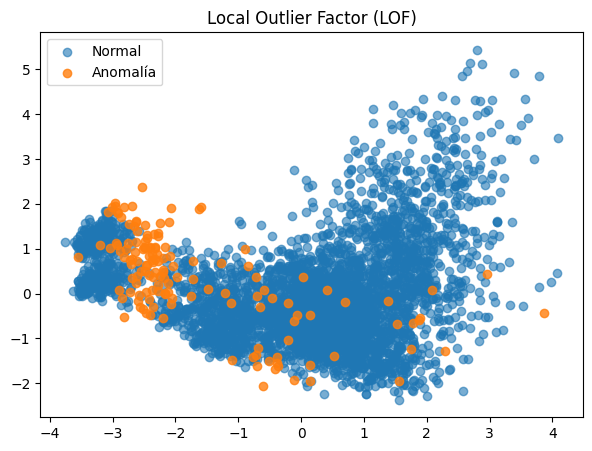

In [ ]:
in_mask = [True if item == 1 else False for item in lof_pred]
out_mask = [True if item == -1 else False for item in lof_pred]

# -------------------------
# Gráfica
# -------------------------
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[lof_pred == 1, 0],
    X_pca[lof_pred == 1, 1],
    alpha=0.6,
    label='Normal'
)
plt.scatter(
    X_pca[lof_pred == -1, 0],
    X_pca[lof_pred == -1, 1],
    alpha=0.8,
    label='Anomalía'
)
plt.title("Local Outlier Factor (LOF)")
plt.legend()
plt.show()

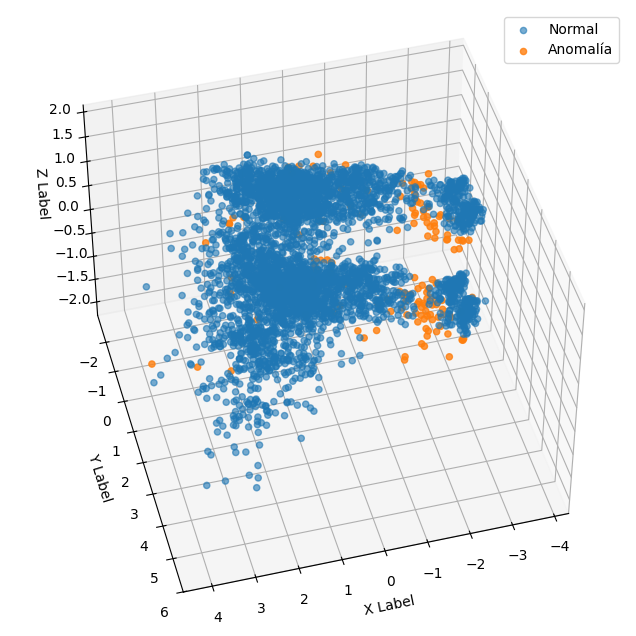

In [ ]:
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d') # or fig.add_subplot(111, projection='3d')

# -------------------------
# Gráfica
# -------------------------
#ax.figure(figsize=(7, 5))
ax.scatter(
    X3d_pca[lof_pred == 1, 0],
    X3d_pca[lof_pred == 1, 1],
    X3d_pca[lof_pred == 1, 2],
    alpha=0.6,
    label='Normal'
)
ax.scatter(
    X3d_pca[lof_pred == -1, 0],
    X3d_pca[lof_pred == -1, 1],
    X3d_pca[lof_pred == -1, 2],
    alpha=0.8,
    label='Anomalía'
)

ax.view_init(elev=45, azim=75)

# 4. Set labels for the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

ax.legend()
# 5. Display the plot
plt.show()

**Gráfico de dispersión de LOF**

En el gráfico, los *outliers* se representan en color naranja y presentan puntuaciones LOF elevadas, mientras que los valores normales aparecen en azul, con puntuaciones cercanas a 1.

LOF identificó un número reducido de anomalías, indicando que existen pocas observaciones que sean atípicas en términos de densidad local.

## OneClassSVM

Es una variante de los modelos *Support Vector Machine* la cual se emplea para detección de anomalías, cuya idea es encontrar un hiperplano que separe los datos atípicos de los normales. Este método no asume una distribución de datos específica.

Parámetros del modelo OneClassSVM

* kernel - Tipo de kernel a usar, puede ser: "linear", "poly", "rbf" y "sigmoid", por default es "rbf"
* degree - Grado del polinomio (kernel polinomial), por default 3
* gamma - Coeficiente para los kernels "poly", "rbf" y "sigmoid". Los valores pueden ser: "scale", "auto" o un número flotante no negativo.
* coef0 - (Flotante) Termino independiente en la función del kernel. Aplica a "poly" y "sigmoid", por defaul es 0.0
* tol - (Flotante) Tolerancia para el criterio de parada, por default (1e-3)
* nu - (Flotante) Límite superior para la fracción de errores de entrenamiento y límite inferior para la fracción de vectores de soporte, por default es 0.5
* cache_size - (Flotante) Especifica el tamaño del kernel en cache (MB), por default 200
* verbose - Habilita la salida
* max_iter - (Entero) Máximo número de iteraciones

In [ ]:
one_SVM = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.05)
one_SVM.fit(X_train)
onesvm_pred = one_SVM.predict(X_train)

In [ ]:
lst_onesvm = []
lst_onesvm.append("OneSVM")
lst_onesvm.append(int((onesvm_pred == 1).sum()))
lst_onesvm.append(int((onesvm_pred == -1).sum()))
lst_outliers.append(lst_onesvm)

Al hacer predicciones con el modelo, **1** indica que el dato es normal y -1 que es un dato atípico.

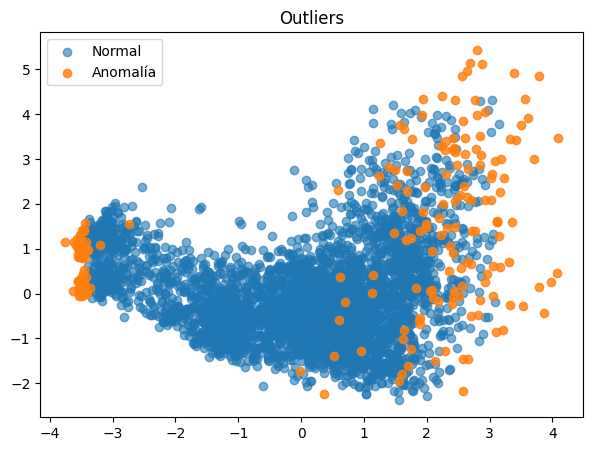

In [ ]:
# -------------------------
# Gráfica
# -------------------------
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[onesvm_pred == 1, 0],
    X_pca[onesvm_pred == 1, 1],
    alpha=0.6,
    label='Normal'
)
plt.scatter(
    X_pca[onesvm_pred == -1, 0],
    X_pca[onesvm_pred == -1, 1],
    alpha=0.8,
    label='Anomalía'
)
plt.title("Outliers")
plt.legend()
plt.show()

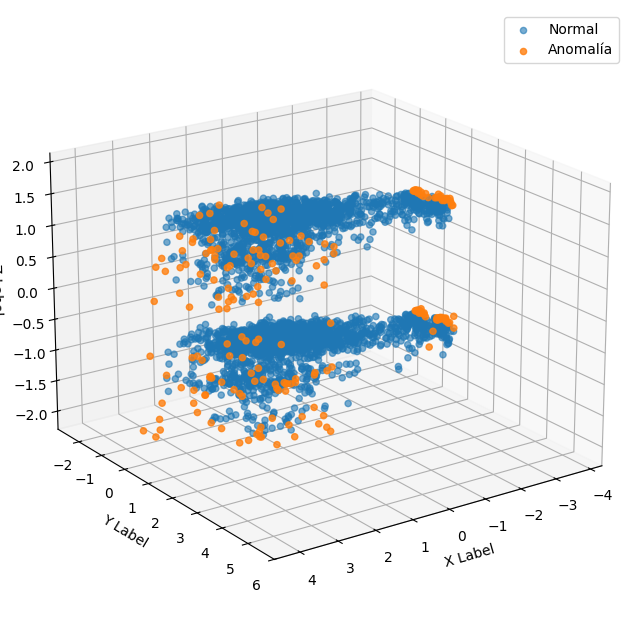

In [ ]:
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3, random_state=42)
X3d_pca = pca_3d.fit_transform(X_train)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d') # or fig.add_subplot(111, projection='3d')

# -------------------------
# Gráfica
# -------------------------
#ax.figure(figsize=(7, 5))
ax.scatter(
    X3d_pca[onesvm_pred == 1, 0],
    X3d_pca[onesvm_pred == 1, 1],
    X3d_pca[onesvm_pred == 1, 2],
    alpha=0.6,
    label='Normal'
)
ax.scatter(
    X3d_pca[onesvm_pred == -1, 0],
    X3d_pca[onesvm_pred == -1, 1],
    X3d_pca[onesvm_pred == -1, 2],
    alpha=0.8,
    label='Anomalía'
)

ax.view_init(elev=20, azim=55)

# 4. Set labels for the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

ax.legend()
# 5. Display the plot
plt.show()

**Gráfico de dispersión**

Muestra los datos normales (puntos azules) y los *outliers* (puntos naranjas). One-Class SVM detectó un subconjunto de anomalías, asociadas a desviaciones respecto al patrón global de normalidad.

In [ ]:
lst_columns=["algorithm", "normal", "outliers"]
df_cmp_outliers = pd.DataFrame(columns=lst_columns, data=lst_outliers)
df_cmp_outliers

,algorithm,normal,outliers
0,Isolation Forest,2315,1772
1,LOF,3941,146
2,OneSVM,3882,205
